In [1]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np
import glob, os
from sklearn.model_selection import train_test_split


In [2]:

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

main_path = "../input/labeled-chest-xray-images/chest_xray"

train_path = os.path.join(main_path, "train")
test_path = os.path.join(main_path, "test")

train_normal = glob.glob(train_path + "/NORMAL/*.jpeg")
train_pneumonia = glob.glob(train_path + "/PNEUMONIA/*.jpeg")

test_normal = glob.glob(test_path + "/NORMAL/*.jpeg")
test_pneumonia = glob.glob(test_path + "/PNEUMONIA/*.jpeg")


In [3]:

train_list = train_normal + train_pneumonia
train_labels = ['Normal']*len(train_normal) + ['Pneumonia']*len(train_pneumonia)

df_train = pd.DataFrame({
    'image': train_list,
    'class': train_labels
})

test_list = test_normal + test_pneumonia
test_labels = ['Normal']*len(test_normal) + ['Pneumonia']*len(test_pneumonia)

df_test = pd.DataFrame({
    'image': test_list,
    'class': test_labels
})

In [4]:

train_df, val_df = train_test_split(
    df_train,
    test_size=0.2,
    stratify=df_train['class'],
    random_state=SEED
)


In [5]:

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_ds = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = val_datagen.flow_from_dataframe(
    val_df,
    x_col='image',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE
)

test_ds = val_datagen.flow_from_dataframe(
    df_test,
    x_col='image',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=1,
    shuffle=False
)


Found 4185 validated image filenames belonging to 2 classes.
Found 1047 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.


In [6]:

base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False  


94773248/94765736 [==============================] - 0s 0us/step


In [7]:

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])


In [8]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 7, 7, 2048)        23587712  
_________________________________________________________________
global_average_pooling2d (Gl (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 128)               262272    
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 129       
Total params: 23,850,113
Trainable params: 262,401
Non-trainable params: 23,587,712
_________________________________________________________________


In [9]:

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
131/131 [==============================] - 142s 1s/step - loss: 0.6009 - accuracy: 0.7224 - val_loss: 0.5536 - val_accuracy: 0.7421
Epoch 2/20
131/131 [==============================] - 103s 784ms/step - loss: 0.5679 - accuracy: 0.7376 - val_loss: 0.5362 - val_accuracy: 0.7421
Epoch 3/20
131/131 [==============================] - 102s 779ms/step - loss: 0.5487 - accuracy: 0.7388 - val_loss: 0.5208 - val_accuracy: 0.7421
Epoch 4/20
131/131 [==============================] - 101s 771ms/step - loss: 0.5313 - accuracy: 0.7409 - val_loss: 0.5070 - val_accuracy: 0.7402
Epoch 5/20
131/131 [==============================] - 101s 772ms/step - loss: 0.5111 - accuracy: 0.7465 - val_loss: 0.4996 - val_accuracy: 0.7479
Epoch 6/20
131/131 [==============================] - 101s 773ms/step - loss: 0.4966 - accuracy: 0.7541 - val_loss: 0.4808 - val_accuracy: 0.7517
Epoch 7/20
131/131 [==============================] - 101s 772ms/step - loss: 0.5000 - accuracy: 0.7344 - val_loss: 0.4670 - va

In [10]:

val_loss, val_acc = model.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

33/33 [==============================] - 12s 376ms/step - loss: 0.3829 - accuracy: 0.8214
Validation Accuracy: 0.8213944435119629
624/624 [==============================] - 14s 21ms/step - loss: 0.4963 - accuracy: 0.7452
Test Accuracy: 0.745192289352417


In [11]:
# Unfreeze top layers
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompile with low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train again
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
131/131 [==============================] - 108s 799ms/step - loss: 0.6331 - accuracy: 0.7362 - val_loss: 0.4543 - val_accuracy: 0.8539
Epoch 2/10
131/131 [==============================] - 104s 795ms/step - loss: 0.2429 - accuracy: 0.9001 - val_loss: 0.3409 - val_accuracy: 0.8329
Epoch 3/10
131/131 [==============================] - 101s 773ms/step - loss: 0.2283 - accuracy: 0.9066 - val_loss: 0.2591 - val_accuracy: 0.8730
Epoch 4/10
131/131 [==============================] - 103s 787ms/step - loss: 0.1967 - accuracy: 0.9267 - val_loss: 0.1543 - val_accuracy: 0.9417
Epoch 5/10
131/131 [==============================] - 103s 790ms/step - loss: 0.2013 - accuracy: 0.9209 - val_loss: 0.1346 - val_accuracy: 0.9503
Epoch 6/10
131/131 [==============================] - 103s 783ms/step - loss: 0.1775 - accuracy: 0.9257 - val_loss: 0.1391 - val_accuracy: 0.9465
Epoch 7/10
131/131 [==============================] - 102s 779ms/step - loss: 0.1709 - accuracy: 0.9344 - val_loss: 0.1238 -

In [13]:
# =======================
# PLOTS
# =======================
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    # Accuracy plot
    plt.figure()
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Val Accuracy')
    plt.legend()
    plt.title("Accuracy vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()

    # Loss plot
    plt.figure()
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.legend()
    plt.title("Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()



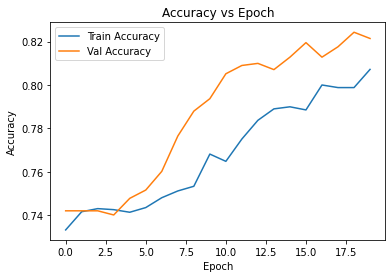

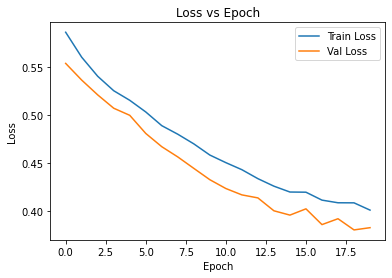


after Finetuning 



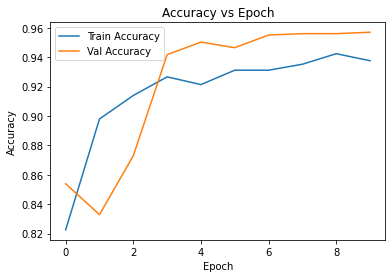

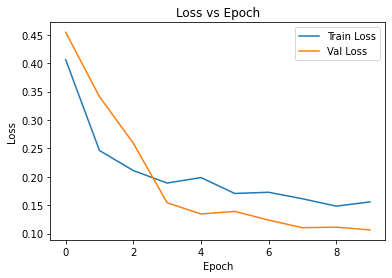

In [15]:
# Plot for initial training
plot_history(history)

print('\nafter Finetuning \n')
# Plot for fine-tuning
plot_history(history_finetune)

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs > 0.7).astype(int).reshape(-1)

# True labels
y_true = test_ds.classes


In [24]:

# =======================
# CLASSIFICATION REPORT
# =======================
print(classification_report(y_true, y_pred, target_names=['Normal','Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.93      0.76      0.84       234
   Pneumonia       0.87      0.97      0.92       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.88       624
weighted avg       0.89      0.89      0.89       624



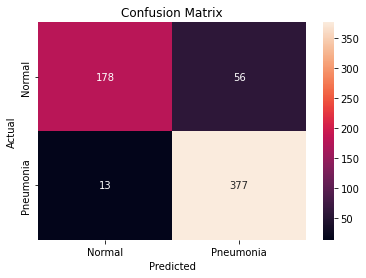

In [25]:

# =======================
# CONFUSION MATRIX
# =======================
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


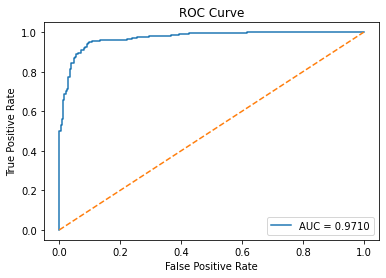

In [26]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
# Save model
model.save("Chest X-Ray_pneumonia_model.h5")